# Restaurant (Fodor’s-Zagat’s) Dataset

> A classic **Entity Resolution / Record Linkage** benchmark built from two restaurant guides: **Fodor’s** and **Zagat’s**.  
> This package contains both **unsegmented** (raw text) and **segmented** (fielded) versions, plus ground truth for matches.

In [3]:
import tarfile, os, re, csv
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from difflib import SequenceMatcher

## 1. What this dataset is for

The goal is to identify which records from **two different sources** refer to the **same real-world restaurant**.

- Source A: **Fodor’s** guide records  
- Source B: **Zagat’s** guide records  
- Task: find the **true matching pairs** across sources (entity linkage / record linkage).

A key property is **extreme class imbalance** in pair space (very few true matches among all possible pairs), which makes **blocking/candidate generation** essential for practical ER experiments.

In [4]:
!tree data

data
├── fz.arff
├── fz-nophone.arff
├── original
│   ├── fodors.txt
│   ├── match-pairs.txt
│   └── zagats.txt
└── README

2 directories, 6 files


## 2. Files included in this package (from `restaurant.tar.gz`)

This archive contains:

### Unsegmented (raw) versions
- You can immediately do ER with string similarity, token similarity, ML models, etc.
- `restaurant/original/fodors.txt` - **533** Fodor’s records (one record per line, raw / unsegmented)
- `restaurant/original/zagats.txt` - **331** Zagat’s records (one record per line, raw / unsegmented)
- `restaurant/original/match-pairs.txt` - **112** gold matching pairs (paired raw entries separated by `########################`)

### Segmented (fielded) versions
- Records are raw text lines where name/address/city/phone/type can be interleaved and irregular.
This adds an extra task:
- **record parsing / field extraction**
before you can run the ER/linkage pipeline.
- `restaurant/fz.arff` - **864** segmented records (**includes phone**)
- `restaurant/fz-nophone.arff` - **864** segmented records (**phone removed**)  
- `restaurant/README` - package notes (incl. warning that *phone makes the task too easy*)

Sanity check: **533 + 331 = 864** total records.

In [5]:
!head -n 10 data/original/fodors.txt

Adriano's Ristorante 2930 Beverly Glen Circle Los Angeles 310/475-9807 Italian
Arnie Morton's of Chicago 435 S. La Cienega Blvd. Los Angeles 310/246-1501 American
Art's Delicatessen 12224 Ventura Blvd. Studio City 818/762-1221 American
Barney Greengrass 9570 Wilshire Blvd. Beverly Hills 310/777-5877 American
Beaurivage 26025 Pacific Coast Hwy. Malibu 310/456-5733 French
Bistro Garden 176 N. Canon Dr. Los Angeles 310/550-3900 Californian
Border Grill 4th St. Los Angeles 310/451-1655 Mexican
Broadway Deli 3rd St. Promenade Santa Monica 310/451-0616 American
Ca'Brea 346 S. La Brea Ave. Los Angeles 213/938-2863 Italian
Ca'del Sol 4100 Cahuenga Blvd. Los Angeles 818/985-4669 Italian


In [6]:
!wc -l data/original/fodors.txt

533 data/original/fodors.txt


In [7]:
!head -n 10 data/original/zagats.txt

Apple Pan  The 10801 W. Pico Blvd. West LA 310-475-3585 American
Arnie Morton's of Chicago 435 S. La Cienega Blvd. Los Angeles 310-246-1501 Steakhouses
Art's Deli 12224 Ventura Blvd. Studio City 818-762-1221 Delis
Asahi Ramen 2027 Sawtelle Blvd. West LA 310-479-2231 Noodle Shops
Baja Fresh 3345 Kimber Dr. Westlake Village 805-498-4049 Mexican
Bel-Air Hotel 701 Stone Canyon Rd. Bel Air 310-472-1211 Californian
Belvedere  The 9882 Little Santa Monica Blvd. Beverly Hills 310-788-2306 Pacific New Wave
Benita's Frites 1433 Third St. Promenade Santa Monica 310-458-2889 Fast Food
Bernard's 515 S. Olive St. Los Angeles 213-612-1580 Continental
Bistro 45 45 S. Mentor Ave. Pasadena 818-795-2478 Californian


In [8]:
!wc -l data/original/zagats.txt

331 data/original/zagats.txt


In [9]:
!head -n 30 data/original/match-pairs.txt

###################################################################################################
# 
#   There are 112 matches between the tuples.  The Zagat tuple is listed first, 
#   and then its Fodors pair.
#
###################################################################################################


Arnie Morton's of Chicago 435 S. La Cienega Blvd. Los Angeles 310-246-1501 Steakhouses


Arnie Morton's of Chicago 435 S. La Cienega Blvd. Los Angeles 310/246-1501
 American
########################

Art's Deli 12224 Ventura Blvd. Studio City 818-762-1221 Delis


Art's Delicatessen 12224 Ventura Blvd. Studio City 818/762-1221 American
########################

Bel-Air Hotel 701 Stone Canyon Rd. Bel Air 310-472-1211 Californian


Hotel Bel-Air 701 Stone Canyon Rd. Bel Air 310/472-1211 Californian
########################

Cafe Bizou 14016 Ventura Blvd. Sherman Oaks 818-788-3536 French Bistro




In [29]:
!grep -c '^########################$' data/original/match-pairs.txt

110


## 3. Schema of the segmented data (`.arff`)

### `fz.arff` columns
- `name` (string)
- `addr` (string)
- `city` (string)
- `phone` (string)
- `type` (string; cuisine/category)
- `class` (integer)

### `fz-nophone.arff` columns
- `name`
- `addr`
- `city`
- `type`
- `class`

✅ Important: **`class` is NOT a binary label (match/non-match)**.  
It is an **entity/cluster identifier**: records with the same `class` refer to the same real-world restaurant.

That means this dataset supports:
- **pairwise linkage evaluation** (derive positive pairs from same-`class` with size 2)
- **clustering evaluation** (connected components / union-find / assignment)

In [15]:
EXTRACT_DIR = Path("data/")

In [16]:
paths = list(EXTRACT_DIR.rglob("*"))
[f for f in paths if f.name.lower().endswith(".arff")], [f for f in paths if f.name.lower() == "readme"][:3]

([PosixPath('data/fz-nophone.arff'), PosixPath('data/fz.arff')],
 [PosixPath('data/README')])

In [18]:
def load_arff_to_df(arff_path: Path) -> pd.DataFrame:
    """
    Minimal ARFF loader for this dataset.
    Handles:
      - @attribute lines
      - @data lines
      - quoted strings with single quotes
      - missing values '?'
    """
    attr_names = []
    data_lines = []
    in_data = False
    with open(arff_path, "r", encoding="utf-8", errors="replace") as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith("%"):
                continue
            low = line.lower()
            if low.startswith("@attribute"):
                # Format: @attribute name type
                # name might be quoted; in this dataset it's plain.
                parts = line.split(None, 2)
                if len(parts) >= 2:
                    name = parts[1].strip()
                    # strip quotes if any
                    if (name.startswith("'") and name.endswith("'")) or (name.startswith('"') and name.endswith('"')):
                        name = name[1:-1]
                    attr_names.append(name)
            elif low.startswith("@data"):
                in_data = True
            elif in_data:
                data_lines.append(line)
    
    rows = []
    for line in data_lines:
        # parse CSV respecting quotes
        reader = csv.reader([line], delimiter=",", quotechar="'", escapechar="\\", skipinitialspace=True)
        fields = next(reader)
        # normalize length
        if len(fields) != len(attr_names):
            # Some ARFF lines might have trailing commas etc; do a fallback split
            fields = [x.strip() for x in line.split(",")]
        row = {}
        for k, v in zip(attr_names, fields):
            v = v.strip()
            if v == "?":
                row[k] = None
            else:
                # remove wrapping quotes if present
                if (v.startswith("'") and v.endswith("'")) or (v.startswith('"') and v.endswith('"')):
                    v = v[1:-1]
                row[k] = v
        rows.append(row)
    df = pd.DataFrame(rows)
    # try to cast class to int if present
    if "class" in df.columns:
        df["class"] = pd.to_numeric(df["class"], errors="coerce").astype("Int64")
    return df

fz = load_arff_to_df(EXTRACT_DIR / "fz.arff")
fz_nophone = load_arff_to_df(EXTRACT_DIR / "fz-nophone.arff")

fz.shape, fz_nophone.shape, fz.columns.tolist()


((864, 6), (864, 5), ['name', 'addr', 'city', 'phone', 'type', 'class'])

In [20]:
fz.head(10)

,name,addr,city,phone,type,class
0,arnie morton's of chicago,435 s. la cienega blv.,los angeles,310/246-1501,american,0
1,arnie morton's of chicago,435 s. la cienega blvd.,los angeles,310-246-1501,steakhouses,0
2,art's delicatessen,12224 ventura blvd.,studio city,818/762-1221,american,1
3,art's deli,12224 ventura blvd.,studio city,818-762-1221,delis,1
4,hotel bel-air,701 stone canyon rd.,bel air,310/472-1211,californian,2
5,bel-air hotel,701 stone canyon rd.,bel air,310-472-1211,californian,2
6,cafe bizou,14016 ventura blvd.,sherman oaks,818/788-3536,french,3
7,cafe bizou,14016 ventura blvd.,sherman oaks,818-788-3536,french bistro,3
8,campanile,624 s. la brea ave.,los angeles,213/938-1447,american,4
9,campanile,624 s. la brea ave.,los angeles,213-938-1447,californian,4


In [22]:
fz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864 entries, 0 to 863
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    864 non-null    object
 1   addr    864 non-null    object
 2   city    864 non-null    object
 3   phone   864 non-null    object
 4   type    864 non-null    object
 5   class   864 non-null    Int64 
dtypes: Int64(1), object(5)
memory usage: 41.5+ KB


In [30]:
def sim(a, b):
    if a is None or b is None:
        return None
    return SequenceMatcher(None, str(a), str(b)).ratio()

# Build matched-pair dataframe for classes with size 2
pairs = []
for cid, grp in fz_nophone.groupby("class"):
    if len(grp) == 2:
        r1, r2 = grp.iloc[0], grp.iloc[1]
        pairs.append({
            "class": int(cid),
            "name_sim": sim(r1["name"], r2["name"]),
            "addr_sim": sim(r1["addr"], r2["addr"]),
            "city_sim": sim(r1["city"], r2["city"]),
            "type_sim": sim(r1["type"], r2["type"]),
        })
pairs_df = pd.DataFrame(pairs)

pairs_df.describe().T


,count,mean,std,min,25%,50%,75%,max
class,112.0,55.500000,32.475632,0.000000,27.750000,55.500000,83.250000,111.0
name_sim,112.0,0.903394,0.185023,0.272727,0.939313,1.000000,1.000000,1.0
addr_sim,112.0,0.875159,0.207153,0.206897,0.846890,1.000000,1.000000,1.0
city_sim,112.0,0.853617,0.206589,0.166667,0.761905,1.000000,1.000000,1.0
type_sim,112.0,0.575004,0.283961,0.000000,0.300000,0.571895,0.727273,1.0


In [31]:
def phone_digits(s):
    if s is None:
        return None
    return re.sub(r"\D+", "", str(s))

# Matched pairs for phone comparison (use fz with phone)
phone_pairs = []
for cid, grp in fz.groupby("class"):
    if len(grp) == 2:
        p1 = phone_digits(grp.iloc[0]["phone"])
        p2 = phone_digits(grp.iloc[1]["phone"])
        phone_pairs.append((int(cid), p1, p2, p1 == p2))
phone_pairs_df = pd.DataFrame(phone_pairs, columns=["class", "p1", "p2", "digits_equal"])
phone_pairs_df["digits_equal"].value_counts().to_dict(), phone_pairs_df[~phone_pairs_df["digits_equal"]].head()


({True: 108, False: 4},
     class          p1          p2  digits_equal
 64     64  2123151726  2122457992         False
 69     69  7027325111  7027325651         False
 70     70  7027317547  7027317110         False
 71     71  7023853232  7023856277         False)

## 4. Ground truth structure (what "112 duplicates" means here)

From `fz-nophone.arff` (computed from your archive):

- Total records: **864**
- Distinct real-world restaurants (clusters): **752**
- Cluster size distribution:
  - **640** clusters of size **1** (restaurant appears in only one source)
  - **112** clusters of size **2** (restaurant appears in both sources) ✅

So the “**112 duplicates**” correspond exactly to **112 matched entities**, each with **two records (one per guide)**.

### Class ID ranges (observed in this package)
- `class = 0..111` → always size **2** (the 112 true cross-source matches)
- `class = 112..533` → size **1** (Fodor-only singletons)
- `class = 534..752` → size **1** (Zagat-only singletons)

This makes the dataset essentially a **bipartite linkage** problem with at most **1–1** matching per entity.

In [23]:
# Basic stats
cluster_sizes = fz_nophone["class"].value_counts().sort_index()
cluster_size_counts = cluster_sizes.value_counts().sort_index()  # how many clusters of size k

n_clusters = cluster_sizes.shape[0]
n_records = len(fz_nophone)
n_pairs = int((cluster_sizes == 2).sum())  # number of matched entities
n_singletons = int((cluster_sizes == 1).sum())

(n_records, n_clusters, n_pairs, n_singletons, cluster_size_counts.to_dict())


(864, 752, 112, 640, {np.int64(1): 640, np.int64(2): 112})

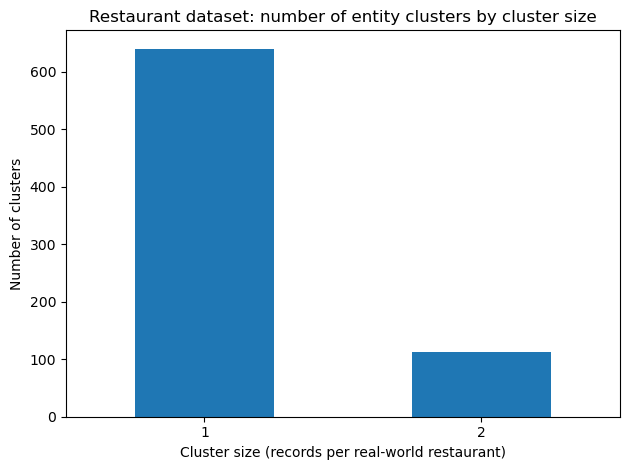

In [35]:
# Plot 1: cluster size distribution (bar)
plt.figure()
cluster_size_counts.plot(kind="bar")
plt.title("Restaurant dataset: number of entity clusters by cluster size")
plt.xlabel("Cluster size (records per real-world restaurant)")
plt.ylabel("Number of clusters")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [24]:
fz['class'].value_counts()

class
0      2
1      2
2      2
3      2
4      2
      ..
748    1
749    1
750    1
751    1
752    1
Name: count, Length: 752, dtype: Int64

In [25]:
fz['type'].value_counts()

type
american       152
italian         98
asian           75
french          64
californian     30
              ... 
pan-asian        1
polish           1
sandwiches       1
spanish          1
cambodian        1
Name: count, Length: 84, dtype: int64

In [26]:
fz['city'].value_counts()

city
new york             250
san francisco        148
atlanta              120
new york city         88
los angeles           74
las vegas             63
la                    15
santa monica          14
beverly hills          8
brooklyn               6
pasadena               6
w. hollywood           6
studio city            5
queens                 5
west la                4
malibu                 4
sherman oaks           3
venice                 3
los feliz              2
bel air                2
hollywood              2
chinatown              2
westwood               2
encino                 2
westlake village       2
roswell                2
marietta               2
decatur                2
duluth                 2
mar vista              1
northridge             1
toluca lake            1
pacific palisades      1
rancho park            1
st. boyle hts.         1
century city           1
long beach             1
culver city            1
redondo beach          1
marina del rey      

In [27]:
fz['name'].value_counts()

name
palace court         2
plumpjack cafe       2
postrio              2
chin's               2
rose pistola         2
                    ..
le gamin             1
le jardin            1
le madri             1
le marais            1
l'auberge du midi    1
Name: count, Length: 776, dtype: int64

## 5. Pair-space imbalance (why blocking matters)

If you compare **every** Fodor record with **every** Zagat record:

\[
533 \times 331 = 176{,}423 \text{ candidate pairs}
\]

True matches: **112**

Positive rate:
\[
\frac{112}{176{,}423} \approx 0.0635\%
\]

That’s why any serious ER pipeline needs **candidate generation** (blocking) before scoring.

## 6. The "phone makes it trivial" issue

Using `fz.arff` (with phone), for the **112** matched pairs:

- After normalizing phone to digits-only (`remove_non_digits`), **108/112** pairs have **identical phone digits**.
- Only **4** matched pairs have different digit strings.

This is why `README` recommends using **`fz-nophone.arff`** for meaningful algorithm comparisons.

In [32]:
def phone_digits(s):
    if s is None:
        return None
    return re.sub(r"\D+", "", str(s))

# Matched pairs for phone comparison (use fz with phone)
phone_pairs = []
for cid, grp in fz.groupby("class"):
    if len(grp) == 2:
        p1 = phone_digits(grp.iloc[0]["phone"])
        p2 = phone_digits(grp.iloc[1]["phone"])
        phone_pairs.append((int(cid), p1, p2, p1 == p2))
phone_pairs_df = pd.DataFrame(phone_pairs, columns=["class", "p1", "p2", "digits_equal"])
phone_pairs_df["digits_equal"].value_counts().to_dict(), phone_pairs_df[~phone_pairs_df["digits_equal"]].head()


({True: 108, False: 4},
     class          p1          p2  digits_equal
 64     64  2123151726  2122457992         False
 69     69  7027325111  7027325651         False
 70     70  7027317547  7027317110         False
 71     71  7023853232  7023856277         False)

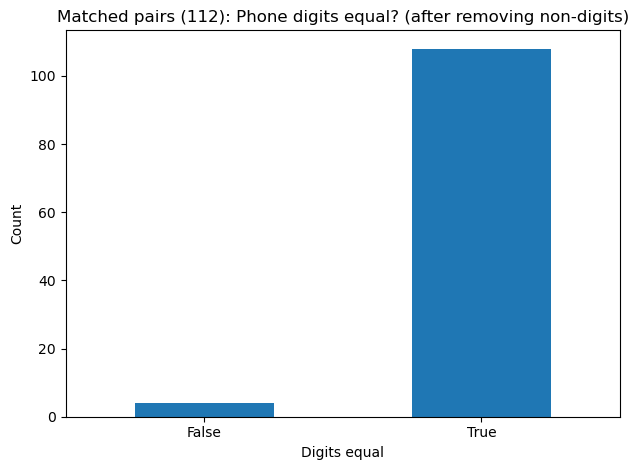

digits_equal
False      4
True     108
Name: count, dtype: int64

In [ ]:
counts = phone_pairs_df["digits_equal"].value_counts().sort_index()
plt.figure()
counts.plot(kind="bar")
plt.title("Matched pairs (112): Phone digits equal? (after removing non-digits)")
plt.xlabel("Digits equal")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

counts


## 7. Similarity behavior on the true matched pairs (no-phone version)

On the **112** gold matched pairs, a simple sequence-based string similarity typically shows:

- `name` similarity: high on average (many pairs near 1.0, but with hard outliers)
- `addr` similarity: high but with format noise (abbreviations, punctuation, missing pieces)
- `city` similarity: good but needs normalization (`LA` vs `Los Angeles`, `W. Hollywood` vs `Hollywood`)
- `type` similarity: usually the weakest / noisiest (categories differ across guides)

Takeaway:
- **Name + address + city** carry most of the matching signal.
- Treat `type` as a **soft feature** (low weight or robust encoding).

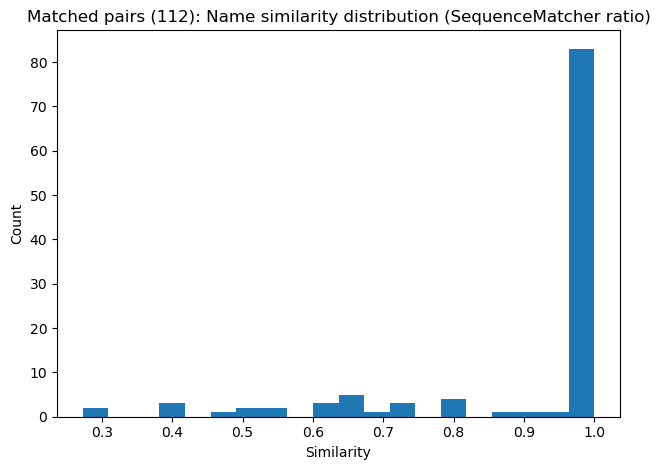

In [36]:
# Plot 2: histogram of name similarity (matched pairs, nophone)
plt.figure()
plt.hist(pairs_df["name_sim"], bins=20)
plt.title("Matched pairs (112): Name similarity distribution (SequenceMatcher ratio)")
plt.xlabel("Similarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


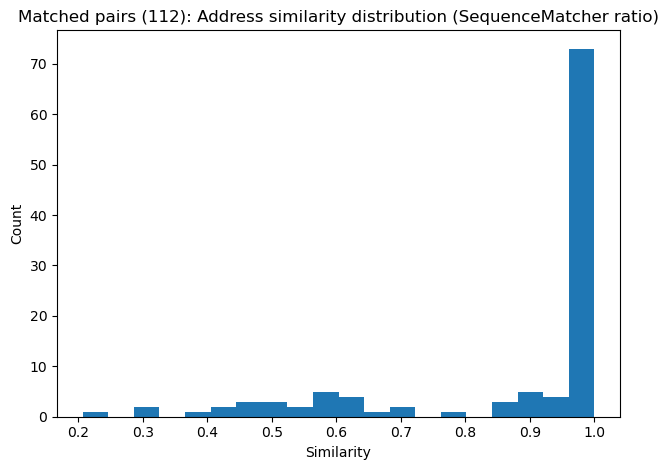

In [37]:
# Plot 3: histogram of address similarity (matched pairs, nophone)
plt.figure()
plt.hist(pairs_df["addr_sim"], bins=20)
plt.title("Matched pairs (112): Address similarity distribution (SequenceMatcher ratio)")
plt.xlabel("Similarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


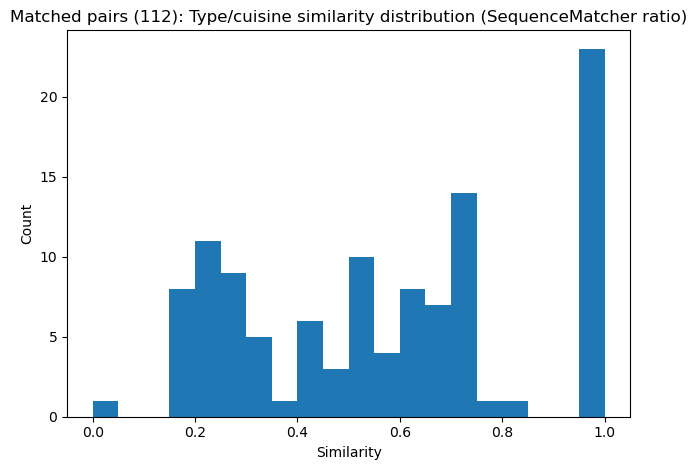

In [38]:
# Extra plot: type similarity distribution (often the weakest signal)
plt.figure()
plt.hist(pairs_df["type_sim"], bins=20)
plt.title("Matched pairs (112): Type/cuisine similarity distribution (SequenceMatcher ratio)")
plt.xlabel("Similarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 8. Quick gotchas

- **`class` is an entity ID**, not binary labels.
- **Phone dominates** if included.
- `type` may hurt if weighted too heavily.
- City names vary; normalize aggressively.
- For fair comparison across methods, report both:
  - *candidate pairs evaluated* (efficiency)
  - *final PR/F1* (effectiveness)

## 9. Recommended experimental setups

### Setup A - clean ER benchmark (recommended)
Use **`fz-nophone.arff`**.

Pipeline:
1. **Normalization**
   - lowercasing, whitespace collapse
   - standardize abbreviations: `st` ↔ `street`, `ave` ↔ `avenue`, etc.
2. **Blocking (candidate generation)**
   - examples: block by normalized `city`, or `(city + first token of name)`, or phonetic keys
3. **Pair scoring**
   - Jaro-Winkler / Levenshtein / token Jaccard / TF-IDF cosine on `name`, `addr`
   - lighter weight features on `city`, `type`
4. **Decision**
   - thresholding OR (better) **maximum bipartite matching** per block
5. **Evaluation**
   - Pairwise Precision / Recall / F1 on the 112 gold matches

### Setup B - "cheating" upper bound
Use **`fz.arff`** with phone digits normalization.  
This should yield near-perfect linkage and is mainly useful as a sanity check.

## 10. Suggested baseline